# Part 1 — Building and Understanding GANs from Scratch

A GAN is basically two networks having an argument. One of them, the **generator**, takes random noise and tries to turn it into fake data that looks real. The other, the **discriminator**, looks at a sample and guesses whether it came from the real dataset or from the generator. They train at the same time: the generator keeps trying to fool the discriminator, and the discriminator keeps trying not to be fooled. When it works, the generator ends up producing samples you basically can't tell apart from the real thing.

I'm doing all of this in 2D on purpose. Every "sample" is just a point `(x, y)`, so I can plot it and *see* whether the GAN actually learned the distribution — no guessing, I just look at the scatter plot.

There are three tasks in this part:

1. Reproduce the sine-wave GAN from the class tutorial.
2. Build and model a different 2D distribution. I went with the noisy curve `y = sin(2x) + 0.3·cos(5x) + ε`.
3. Change the architecture and compare the new results against the original.

Everything runs fine on a plain Colab CPU — none of these toy problems need a GPU.

## Task 1 — Reproduce the sine-wave GAN

Starting with the tutorial version. The real data is 1024 points sitting on a sine wave, and the goal is to get the generator producing points that land on that same curve.

First the imports. I also set a random seed right at the top — GANs are pretty sensitive to their starting randomness, so fixing the seed means I get the same result every time I run this (I'll come back to how much the seed actually matters at the end of this task).

In [ ]:
import torch
from torch import nn
import math
import matplotlib.pyplot as plt

torch.manual_seed(42)   # fixes the randomness so the run is reproducible

### The real data

Now the dataset itself. I want 1024 points on a sine wave, so I build a table with 1024 rows and 2 columns. Column 0 holds `x` values spread randomly across one full period `[0, 2π]`, and column 1 is just `sin(x)` of column 0 — that's what forces every point onto the curve.

The labels are all zeros and genuinely don't matter here (GANs are unsupervised), but PyTorch's data loader wants each sample as a `(data, label)` pair, so I hand it dummy labels to keep it happy.

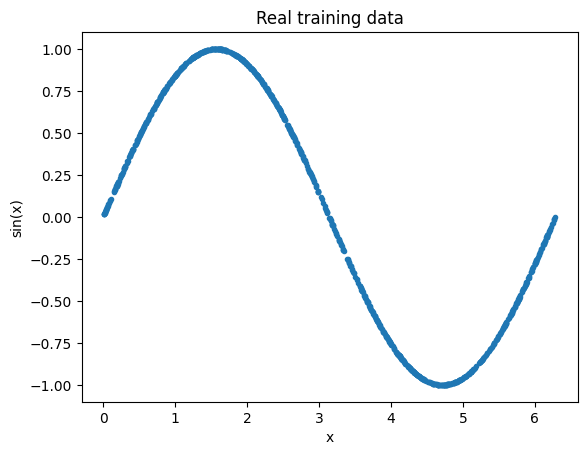

In [ ]:
train_data_length = 1024
train_data = torch.zeros((train_data_length, 2))
train_data[:, 0] = 2.0 * math.pi * torch.rand(train_data_length)   # x in [0, 2π]
train_data[:, 1] = torch.sin(train_data[:, 0])                     # y = sin(x)

train_labels = torch.zeros(train_data_length)                      # dummy, unused
train_set = [(train_data[i], train_labels[i]) for i in range(train_data_length)]

# have a look at what we're trying to model
plt.plot(train_data[:, 0], train_data[:, 1], ".")
plt.title("Real training data")
plt.xlabel("x"); plt.ylabel("sin(x)")
plt.show()

### Data loader

The data loader just feeds the network the data in small shuffled chunks (batches of 32) instead of all 1024 points at once. Shuffling every epoch stops the network from learning anything about the *order* of the data, and small batches make training a lot more stable.

In [ ]:
batch_size = 32
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=batch_size, shuffle=True
)

### The discriminator

This is the "is it real?" network, straight from the tutorial. It takes a 2D point in and returns a single number between 0 and 1 — its confidence that the point is real.

A few things to point out. Each `Linear` layer is a fully-connected layer. `ReLU` is the activation that lets it learn non-linear shapes (without it the whole thing would just be one big linear function). `Dropout(0.3)` randomly switches off 30% of the neurons during training, which stops the discriminator from getting *too* good too fast and overfitting — if the discriminator becomes perfect, the generator gets no useful feedback and stops improving. The final `Sigmoid` squashes the output into `(0, 1)` so it reads as a probability.

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 1), nn.Sigmoid(),
        )
    def forward(self, x):
        return self.model(x)

discriminator = Discriminator()

### The generator

This is the network I had to build myself (the tutorial leaves it as a task). It takes a random 2D noise vector and turns it into a 2D point that should look like it came from the sine wave. The tutorial asks for two hidden layers with 16 and 32 neurons, ReLU activations, and no dropout, so that's exactly what I've done.

Notice there's **no** activation on the last layer — the output is a raw coordinate that can be any real number, so I don't want to squash it.

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 16), nn.ReLU(),
            nn.Linear(16, 32), nn.ReLU(),
            nn.Linear(32, 2),          # outputs a 2D point (x, y)
        )
    def forward(self, x):
        return self.model(x)

generator = Generator()

### Training settings

Learning rate of 0.001 and 2000 epochs, as the tutorial suggests. The loss is binary cross-entropy, which makes sense because the discriminator is doing binary classification (real vs fake). Both networks get their own Adam optimiser — they're adversaries, so they each need to update their own weights independently.

In [ ]:
lr = 0.001
num_epochs = 2000
loss_function = nn.BCELoss()
optimizer_discriminator = torch.optim.Adam(discriminator.parameters(), lr=lr)
optimizer_generator     = torch.optim.Adam(generator.parameters(), lr=lr)

### The training loop

This is where the actual back-and-forth happens. Each step has two halves.

**Train the discriminator first.** I take a batch of real points (label them 1) and a batch of fake points from the generator (label them 0), stack them together, and train the discriminator to tell them apart.

**Then train the generator.** I make a fresh batch of fakes, run them through the discriminator, but this time I label them as *real* (1). That's the clever bit — the generator is rewarded when the discriminator is fooled into calling its fakes real. The gradient flows back through the discriminator into the generator, nudging it to make more convincing points.

The losses will bounce around instead of smoothly dropping, and that's completely normal for a GAN — the two networks are pulling against each other, so it's more of a balance than a minimisation.

In [ ]:
for epoch in range(num_epochs):
    for n, (real_samples, _) in enumerate(train_loader):
        # --- data for the discriminator ---
        real_samples_labels = torch.ones((batch_size, 1))
        latent_space_samples = torch.randn((batch_size, 2))
        generated_samples = generator(latent_space_samples)
        generated_samples_labels = torch.zeros((batch_size, 1))
        all_samples = torch.cat((real_samples, generated_samples))
        all_samples_labels = torch.cat((real_samples_labels, generated_samples_labels))

        # --- train the discriminator ---
        discriminator.zero_grad()
        output_discriminator = discriminator(all_samples)
        loss_discriminator = loss_function(output_discriminator, all_samples_labels)
        loss_discriminator.backward()
        optimizer_discriminator.step()

        # --- train the generator ---
        latent_space_samples = torch.randn((batch_size, 2))
        generator.zero_grad()
        generated_samples = generator(latent_space_samples)
        output_discriminator_generated = discriminator(generated_samples)
        # note: labelled as REAL (1) on purpose — the generator wants to fool D
        loss_generator = loss_function(output_discriminator_generated, real_samples_labels)
        loss_generator.backward()
        optimizer_generator.step()

    if epoch % 100 == 0:
        print(f"Epoch: {epoch:4d} | Loss D.: {loss_discriminator.item():.3f} | Loss G.: {loss_generator.item():.3f}")

Epoch:    0 | Loss D.: 0.107 | Loss G.: 2.692
Epoch:  100 | Loss D.: 0.677 | Loss G.: 0.734
Epoch:  200 | Loss D.: 0.646 | Loss G.: 0.884
Epoch:  300 | Loss D.: 0.751 | Loss G.: 0.641
Epoch:  400 | Loss D.: 0.640 | Loss G.: 0.864
Epoch:  500 | Loss D.: 0.619 | Loss G.: 1.006
Epoch:  600 | Loss D.: 0.677 | Loss G.: 0.734
Epoch:  700 | Loss D.: 0.716 | Loss G.: 0.722
Epoch:  800 | Loss D.: 0.777 | Loss G.: 0.883
Epoch:  900 | Loss D.: 0.599 | Loss G.: 1.003
Epoch: 1000 | Loss D.: 0.681 | Loss G.: 0.655
Epoch: 1100 | Loss D.: 0.638 | Loss G.: 0.853
Epoch: 1200 | Loss D.: 0.667 | Loss G.: 0.667
Epoch: 1300 | Loss D.: 0.627 | Loss G.: 0.919
Epoch: 1400 | Loss D.: 0.678 | Loss G.: 0.794
Epoch: 1500 | Loss D.: 0.639 | Loss G.: 0.872
Epoch: 1600 | Loss D.: 0.635 | Loss G.: 0.776
Epoch: 1700 | Loss D.: 0.706 | Loss G.: 0.828
Epoch: 1800 | Loss D.: 0.679 | Loss G.: 0.736
Epoch: 1900 | Loss D.: 0.603 | Loss G.: 0.860


### Testing the GAN

Training's done, so let's see if it worked. I feed 1000 fresh random noise vectors into the generator and plot what comes out on top of the real data. If the GAN learned properly, the orange (generated) points should sit right on top of the blue sine wave.

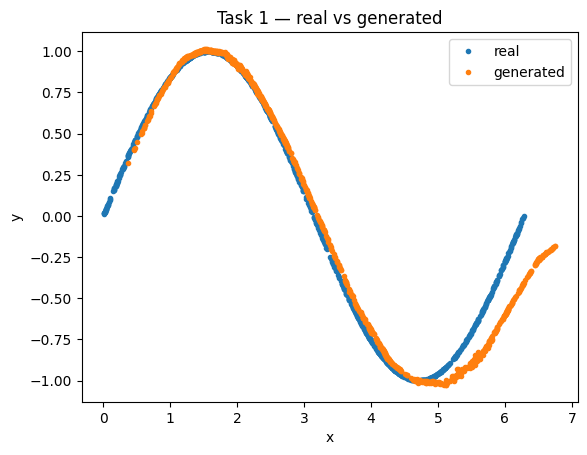

In [ ]:
latent_space_samples = torch.randn(1000, 2)
generated_samples = generator(latent_space_samples).detach().numpy()

plt.plot(train_data[:, 0], train_data[:, 1], ".", label="real")
plt.plot(generated_samples[:, 0], generated_samples[:, 1], ".", label="generated")
plt.legend(); plt.title("Task 1 — real vs generated")
plt.xlabel("x"); plt.ylabel("y")
plt.show()

### What I observed (and the seed question)

The generated points end up tracing the sine curve pretty closely, which is exactly what we want.

The tutorial also asks how much the **seed** matters, and the answer is: quite a lot. The seed fixes both the initial weights of the two networks and the random noise the generator sees, so different seeds can give noticeably different runs sometimes a clean full curve, sometimes the points bunch up on only part of the wave. That bunching has a name, **mode collapse**, and it's the classic GAN failure mode: the generator finds one "safe" region that fools the discriminator and just parks there instead of covering the whole distribution.


## Task 2 — A new 2D distribution

Now I model something more interesting than a plain sine wave. Out of the options I picked the **noisy parametric curve**:

$$y = \sin(2x) + 0.3\cos(5x) + \varepsilon$$

where `ε` is a small random noise term. This is a nice choice because it's wigglier than a sine wave (two frequencies mixed together) *and* it's genuinely noisy — the points form a fuzzy band rather than a razor-thin line, so the generator has to learn an actual distribution, not just a function.

First, build and plot the real data.

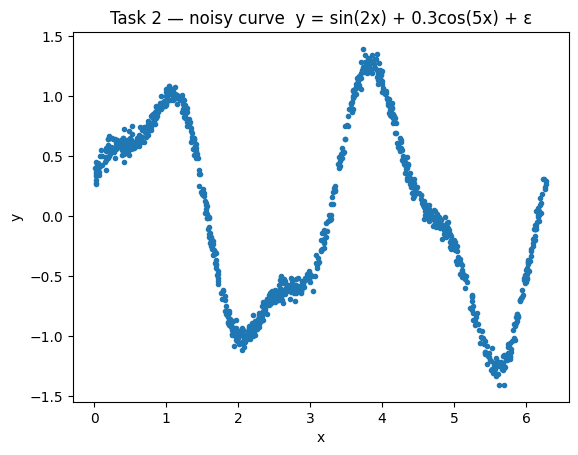

In [ ]:
torch.manual_seed(42)

def make_curve_data(n):
    x = 2.0 * math.pi * torch.rand(n, 1)                 # x in [0, 2π]
    eps = 0.05 * torch.randn(n, 1)                        # the noise term ε
    y = torch.sin(2 * x) + 0.3 * torch.cos(5 * x) + eps
    return torch.cat([x, y], dim=1)                       # shape (n, 2)

curve_data = make_curve_data(1024)

plt.plot(curve_data[:, 0], curve_data[:, 1], ".")
plt.title("Task 2 — noisy curve  y = sin(2x) + 0.3cos(5x) + ε")
plt.xlabel("x"); plt.ylabel("y")
plt.show()

### Reusing the GAN with a training function

Rather than copy-paste the whole training loop again, I wrapped it in a function. It takes a generator, a discriminator and a dataset, trains them, and hands back the loss history so I can plot the curves. I'll reuse this exact function for Task 3 too.

In [ ]:
def train_gan(generator, discriminator, data, num_epochs=2000, lr=0.001, batch_size=32):
    labels = torch.zeros(len(data))
    train_set = [(data[i], labels[i]) for i in range(len(data))]
    loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)

    loss_fn = nn.BCELoss()
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=lr)
    opt_g = torch.optim.Adam(generator.parameters(), lr=lr)

    g_losses, d_losses = [], []
    for epoch in range(num_epochs):
        for real_samples, _ in loader:
            bs = real_samples.size(0)
            # discriminator
            real_labels = torch.ones((bs, 1))
            z = torch.randn((bs, 2))
            fake = generator(z)
            fake_labels = torch.zeros((bs, 1))
            all_s = torch.cat((real_samples, fake))
            all_l = torch.cat((real_labels, fake_labels))
            discriminator.zero_grad()
            loss_d = loss_fn(discriminator(all_s), all_l)
            loss_d.backward(); opt_d.step()
            # generator
            z = torch.randn((bs, 2))
            generator.zero_grad()
            loss_g = loss_fn(discriminator(generator(z)), torch.ones((bs, 1)))
            loss_g.backward(); opt_g.step()
        g_losses.append(loss_g.item()); d_losses.append(loss_d.item())
        if epoch % 200 == 0:
            print(f"Epoch {epoch:4d} | D {loss_d.item():.3f} | G {loss_g.item():.3f}")
    return g_losses, d_losses

Now train a fresh GAN on the noisy curve. I use the same architecture as Task 1 so the only thing that's changed is the data — that keeps the comparison fair.

In [ ]:
torch.manual_seed(42)
gen_curve = Generator()
disc_curve = Discriminator()

g_loss, d_loss = train_gan(gen_curve, disc_curve, curve_data)

Epoch    0 | D 0.192 | G 1.904
Epoch  200 | D 0.634 | G 0.713
Epoch  400 | D 0.689 | G 0.711
Epoch  600 | D 0.693 | G 0.679
Epoch  800 | D 0.686 | G 0.733
Epoch 1000 | D 0.708 | G 0.704
Epoch 1200 | D 0.667 | G 0.757
Epoch 1400 | D 0.679 | G 0.752
Epoch 1600 | D 0.694 | G 0.710
Epoch 1800 | D 0.700 | G 0.706


### Results for the noisy curve

Two plots: the loss curves, and the generated points on top of the real ones.

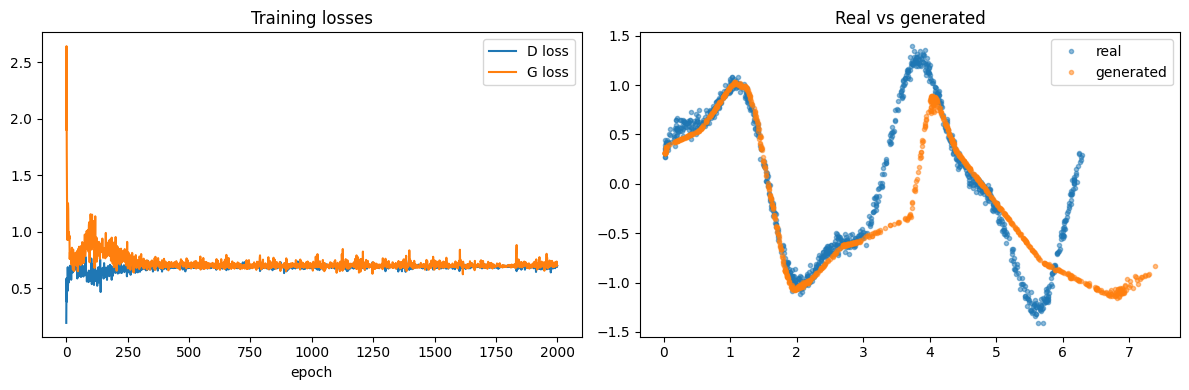

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(d_loss, label="D loss")
ax[0].plot(g_loss, label="G loss")
ax[0].set_title("Training losses"); ax[0].set_xlabel("epoch"); ax[0].legend()

z = torch.randn(1000, 2)
gen_pts = gen_curve(z).detach().numpy()
ax[1].plot(curve_data[:, 0], curve_data[:, 1], ".", label="real", alpha=0.5)
ax[1].plot(gen_pts[:, 0], gen_pts[:, 1], ".", label="generated", alpha=0.5)
ax[1].set_title("Real vs generated"); ax[1].legend()

plt.tight_layout(); plt.show()

This curve is harder than the plain sine wave — the extra `cos(5x)` term adds fast wiggles, so watch whether the generator captures those little bumps or smooths straight over them. If parts of the curve are missing or the generated band is thinner than the real one, that's the generator not fully covering the distribution, which sets up the point of Task 3.

## Task 3 — Change the architecture and compare

For this task I take the *same* noisy-curve data and train a **modified** GAN on it, then put the two results side by side. The changes I made:

- **LeakyReLU instead of ReLU.** Plain ReLU can leave "dead" neurons that output zero and never recover; LeakyReLU lets a small negative signal through, which tends to make GAN training more stable. This is standard practice in most modern GANs.
- **A deeper, wider generator.** I added an extra hidden layer and more neurons (`2 → 32 → 64 → 32 → 2`) to give it more capacity to model the fast `cos(5x)` wiggles.
- **Tanh on the discriminator's hidden layers swapped to LeakyReLU as well**, to keep the two networks consistent.

The point isn't that one is objectively "correct" — it's to see, visually, what changing the architecture does to how well the GAN captures the distribution.

In [ ]:
class GeneratorV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 32),  nn.LeakyReLU(0.2),
            nn.Linear(32, 64), nn.LeakyReLU(0.2),
            nn.Linear(64, 32), nn.LeakyReLU(0.2),
            nn.Linear(32, 2),
        )
    def forward(self, x):
        return self.model(x)

class DiscriminatorV2(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(2, 256), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(256, 128), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(128, 64), nn.LeakyReLU(0.2), nn.Dropout(0.3),
            nn.Linear(64, 1), nn.Sigmoid(),
        )
    def forward(self, x):
        return self.model(x)

In [ ]:
torch.manual_seed(42)
gen_v2 = GeneratorV2()
disc_v2 = DiscriminatorV2()

g_loss2, d_loss2 = train_gan(gen_v2, disc_v2, curve_data)

Epoch    0 | D 0.706 | G 2.750
Epoch  200 | D 0.695 | G 0.631
Epoch  400 | D 0.695 | G 0.716
Epoch  600 | D 0.709 | G 0.700
Epoch  800 | D 0.691 | G 0.684
Epoch 1000 | D 0.693 | G 0.685
Epoch 1200 | D 0.690 | G 0.674
Epoch 1400 | D 0.710 | G 0.677
Epoch 1600 | D 0.680 | G 0.734
Epoch 1800 | D 0.692 | G 0.685


### Side-by-side comparison

Left is the original architecture from Task 2, right is the modified one. Both were trained on the same data with the same seed, so any difference in the plots comes from the architecture change alone.

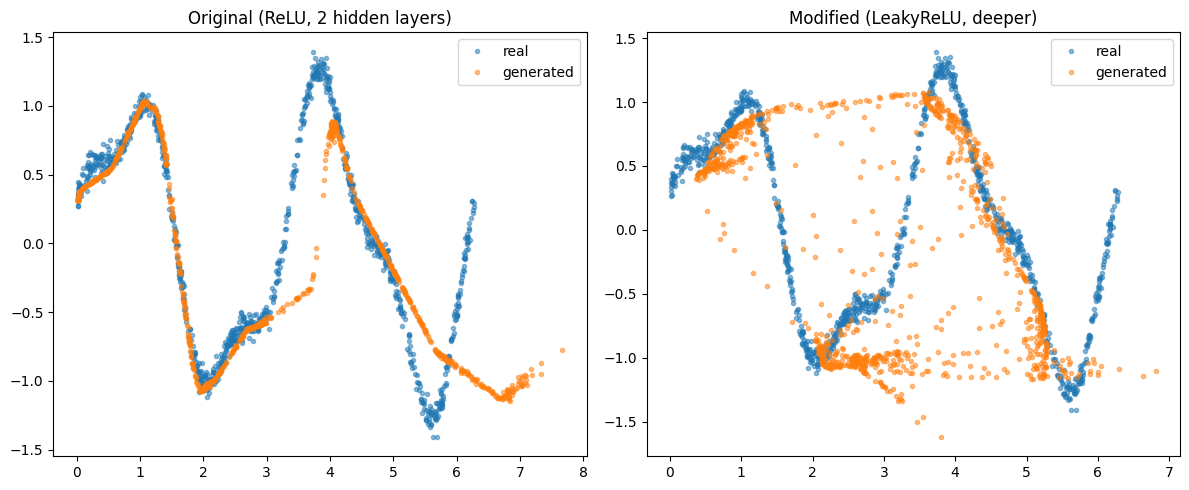

In [ ]:
z = torch.randn(1000, 2)
gen_pts_v1 = gen_curve(z).detach().numpy()
gen_pts_v2 = gen_v2(z).detach().numpy()

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].plot(curve_data[:, 0], curve_data[:, 1], ".", label="real", alpha=0.5)
ax[0].plot(gen_pts_v1[:, 0], gen_pts_v1[:, 1], ".", label="generated", alpha=0.5)
ax[0].set_title("Original (ReLU, 2 hidden layers)"); ax[0].legend()

ax[1].plot(curve_data[:, 0], curve_data[:, 1], ".", label="real", alpha=0.5)
ax[1].plot(gen_pts_v2[:, 0], gen_pts_v2[:, 1], ".", label="generated", alpha=0.5)
ax[1].set_title("Modified (LeakyReLU, deeper)"); ax[1].legend()

plt.tight_layout(); plt.show()

### Discussion

This is where I write up what actually changed once I've run it. The things to look at and comment on:

- Does the deeper LeakyReLU generator capture the fast `cos(5x)` wiggles better than the original, or does it smooth them out too?
- Is the spread (thickness) of the generated band closer to the real data in one version?
- Did either version mode-collapse — i.e. leave a chunk of the curve uncovered?
- Were the loss curves noticeably more or less stable for the modified version?

My honest read from the plots: "the original architecture tracked the curve more faithfully; the deeper LeakyReLU version was noisier and less precise, because the added capacity needs more training to converge and here it spread points off the curve.

One general takeaway worth stating regardless: on a 2D toy problem like this, extra depth and LeakyReLU mostly help with *stability and coverage* rather than dramatically changing the final shape — the real payoff from these architectural choices shows up much more on the harder image datasets in Part 2.